<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QGeno027.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

N_grid = 256
x = np.linspace(0, 2*np.pi, N_grid, endpoint=False)
A = 0.1
sigma = 0.2
theta = np.pi / 3
dt = 0.01
gamma = 0.005
lam = 0.1

def gaussian(center, width, amplitude):
    return amplitude * np.exp(-((x - center)**2) / (2 * width**2))

def laplacian(phi):
    return np.roll(phi, 1) - 2*phi + np.roll(phi, -1)

def evolve(phi):
    lap = laplacian(phi)
    nonlinear = lam * np.clip(phi, -1.0, 1.0)**3
    phi = phi + dt * (lap - gamma * phi + nonlinear)
    return np.clip(phi, -1.0, 1.0)


In [2]:
ensemble_size = 10
lifetimes = []
velocities = []

for run in range(ensemble_size):
    centers = np.random.choice(x, size=5, replace=False)
    nodes = [gaussian(c, sigma, A) * np.cos(theta) for c in centers]
    phi = sum(nodes)
    history = [phi.copy()]

    for t in range(300):
        phi = evolve(phi)
        if t % 10 == 0:
            history.append(phi.copy())

    # Track particles
    trajs = []
    for snapshot in history:
        peaks, _ = find_peaks(snapshot, height=0.02)
        trajs.append(peaks)

    # Compute stats
    for i in range(len(trajs[0])):
        path = [p[i] if i < len(p) else np.nan for p in trajs]
        valid = [v for v in path if not np.isnan(v)]
        if len(valid) > 1:
            lifetime = len(valid)
            velocity = np.abs(valid[-1] - valid[0]) / lifetime
            lifetimes.append(lifetime)
            velocities.append(velocity)


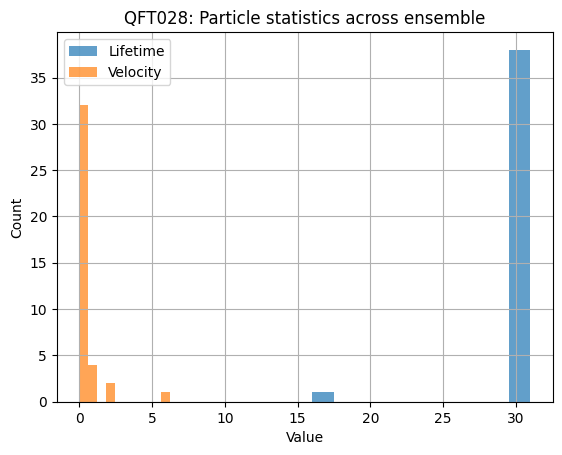

In [3]:
plt.hist(lifetimes, bins=10, alpha=0.7, label="Lifetime")
plt.hist(velocities, bins=10, alpha=0.7, label="Velocity")
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("QFT028: Particle statistics across ensemble")
plt.legend()
plt.grid(True)
plt.show()
